<a href="https://colab.research.google.com/github/parthibanxd/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FlyRank Capstone — Refresh / Content Opportunity Scoring

**Lane:** `decline_recovery`

This notebook builds a leakage-safe recovery model, compares it with a transparent ML-07-style baseline rule, checks deliberate label leakage, and creates a ranked recommendation queue. The data join is implemented in DuckDB to avoid slow row-by-row scans.

**Run:** Execute this notebook top-to-bottom in Google Colab. Metrics are computed from the data at runtime; no performance numbers are fabricated.


In [2]:
!pip -q install duckdb scikit-learn matplotlib

import os
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import userdata
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score

HF_TOKEN = userdata.get("HF_TOKEN")
con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{HF_TOKEN}')")

WAREHOUSE = "hf://datasets/FlyRank/internship-warehouse"

# Time-aware split:
# February decisions -> March outcomes = training
# March decisions -> April outcomes = holdout
# June remains sealed.
TRAIN_DECISION_MONTH = "2026-02"
TRAIN_LABEL_MONTH = "2026-03"
HOLDOUT_DECISION_MONTH = "2026-03"
HOLDOUT_LABEL_MONTH = "2026-04"

def month_path(month):
    return f"{WAREHOUSE}/fact_content_daily_performance/month={month}/*.parquet"

print("Connected.")
print("Train:", TRAIN_DECISION_MONTH, "->", TRAIN_LABEL_MONTH)
print("Holdout:", HOLDOUT_DECISION_MONTH, "->", HOLDOUT_LABEL_MONTH)


Connected.
Train: 2026-02 -> 2026-03
Holdout: 2026-03 -> 2026-04


## 1. Data contract

The primary source is `fact_content_daily_performance`.

One row represents one pseudonymized content item for one pseudonymized client on one report date.

The five decision-time features are:

- `current_position`
- `position_7d_avg`
- `position_change_7d`
- `current_clicks`
- `current_impressions`

The forward-looking `recovery_label` is created separately from future observations and is never used as a model feature.


In [3]:
schema = con.sql(
    "DESCRIBE SELECT * FROM read_parquet('" + month_path("2026-03") + "') LIMIT 1"
).df()

print("March schema:")
display(schema)

march_stats = con.sql(
    "SELECT COUNT(*) AS row_count, "
    "MIN(report_date) AS earliest_date, "
    "MAX(report_date) AS latest_date, "
    "COUNT(DISTINCT (client_hash_id, content_hash_id, report_date)) AS distinct_daily_keys "
    "FROM read_parquet('" + month_path("2026-03") + "')"
).df()

print("March slice:")
display(march_stats)


March schema:


,column_name,column_type,null,key,default,extra
0,report_date,DATE,YES,None,None,None
1,client_hash_id,VARCHAR,YES,None,None,None
2,content_hash_id,VARCHAR,YES,None,None,None
3,client_has_gsc,BOOLEAN,YES,None,None,None
4,client_has_ga4,BOOLEAN,YES,None,None,None
5,gsc_data_available,BOOLEAN,YES,None,None,None
6,ga4_data_available,BOOLEAN,YES,None,None,None
7,gsc_impressions,BIGINT,YES,None,None,None
8,gsc_clicks,BIGINT,YES,None,None,None
9,gsc_sum_position,BIGINT,YES,None,None,None


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

March slice:


,row_count,earliest_date,latest_date,distinct_daily_keys
0,9841378,2026-03-01,2026-03-31,9841378


In [4]:
def load_month(month):
    return con.sql(
        "SELECT client_hash_id, content_hash_id, report_date, "
        "gsc_avg_position, gsc_clicks, gsc_impressions "
        "FROM read_parquet('" + month_path(month) + "') "
        "WHERE gsc_data_available IS TRUE "
        "AND gsc_avg_position IS NOT NULL "
        "AND gsc_avg_position > 0"
    ).df()


def build_dataset(decision_month, label_month):
    """Build decision-time features and a future 14-day recovery label.

    The expensive Python row-by-row scan has intentionally been replaced with
    DuckDB window functions + a range join. This keeps the work inside DuckDB
    and avoids scanning the full future DataFrame once per decision row.
    """
    decision_path = month_path(decision_month)
    future_path = month_path(label_month)

    query = f"""
    WITH decision_base AS (
        SELECT
            client_hash_id,
            content_hash_id,
            CAST(report_date AS DATE) AS report_date,
            gsc_avg_position,
            gsc_clicks,
            gsc_impressions
        FROM read_parquet('{decision_path}')
        WHERE gsc_data_available IS TRUE
          AND gsc_avg_position IS NOT NULL
          AND gsc_avg_position > 0
    ),
    decision_features AS (
        SELECT
            *,
            gsc_avg_position AS current_position,
            AVG(gsc_avg_position) OVER (
                PARTITION BY client_hash_id, content_hash_id
                ORDER BY report_date
                ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING
            ) AS position_7d_avg,
            gsc_avg_position - LAG(gsc_avg_position, 7) OVER (
                PARTITION BY client_hash_id, content_hash_id
                ORDER BY report_date
            ) AS position_change_7d,
            gsc_clicks AS current_clicks,
            gsc_impressions AS current_impressions
        FROM decision_base
    ),
    decisions AS (
        SELECT *
        FROM decision_features
        WHERE position_7d_avg IS NOT NULL
          AND current_position >= position_7d_avg * 1.20
    ),
    future AS (
        SELECT
            client_hash_id,
            content_hash_id,
            CAST(report_date AS DATE) AS report_date,
            gsc_avg_position
        FROM read_parquet('{future_path}')
        WHERE gsc_data_available IS TRUE
          AND gsc_avg_position IS NOT NULL
          AND gsc_avg_position > 0
    ),
    labeled AS (
        SELECT
            d.client_hash_id,
            d.content_hash_id,
            d.report_date,
            d.current_position,
            d.position_7d_avg,
            d.position_change_7d,
            d.current_clicks,
            d.current_impressions,
            CASE
                WHEN MIN(f.gsc_avg_position) <= d.position_7d_avg * 1.20
                THEN 1 ELSE 0
            END AS recovery_label
        FROM decisions d
        LEFT JOIN future f
          ON f.client_hash_id = d.client_hash_id
         AND f.content_hash_id = d.content_hash_id
         AND f.report_date > d.report_date
         AND f.report_date <= d.report_date + INTERVAL 14 DAY
        GROUP BY
            d.client_hash_id,
            d.content_hash_id,
            d.report_date,
            d.current_position,
            d.position_7d_avg,
            d.position_change_7d,
            d.current_clicks,
            d.current_impressions
    )
    SELECT * FROM labeled
    ORDER BY client_hash_id, content_hash_id, report_date
    """

    return con.sql(query).df()


train_df = build_dataset(TRAIN_DECISION_MONTH, TRAIN_LABEL_MONTH)
holdout_df = build_dataset(HOLDOUT_DECISION_MONTH, HOLDOUT_LABEL_MONTH)

print("Training rows:", len(train_df))
print("Holdout rows:", len(holdout_df))

print("Training labels:")
display(train_df["recovery_label"].value_counts().rename_axis("label").to_frame("n"))

print("Holdout labels:")
display(holdout_df["recovery_label"].value_counts().rename_axis("label").to_frame("n"))


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Training rows: 626116
Holdout rows: 957397
Training labels:


,n
label,
0,353890
1,272226


Holdout labels:


,n
label,
0,595205
1,362192


## 2. Model features

These features are knowable at the decision moment:

1. `current_position` — today's observed position.
2. `position_7d_avg` — trailing seven observations before the decision.
3. `position_change_7d` — today's position versus seven observations earlier.
4. `current_clicks` — today's clicks.
5. `current_impressions` — today's impressions.

No future recovery information is included.


In [5]:
feature_cols = [
    "current_position",
    "position_7d_avg",
    "position_change_7d",
    "current_clicks",
    "current_impressions"
]

train_model = train_df.dropna(
    subset=feature_cols + ["recovery_label"]
).copy()

holdout_model = holdout_df.dropna(
    subset=feature_cols + ["recovery_label"]
).copy()

print("Train rows:", len(train_model))
print("Holdout rows:", len(holdout_model))
print("Missing values:")
display(train_model[feature_cols].isna().sum().to_frame("missing"))


Train rows: 420845
Holdout rows: 648376
Missing values:


,missing
current_position,0
position_7d_avg,0
position_change_7d,0
current_clicks,0
current_impressions,0


## 3. ML-07 baseline

The original ML-07 rule is:

- staleness: 0–40 points after 30 days, reaching 40 at 180 days;
- CTR-position: 0–60 points for average position 4–20 and at least 100 recent impressions;
- lower CTR gets a larger score, capped at 0.30%;
- the larger component selects one reason code and one action label.

If the supplied ML-07 baseline CSV exists in the repository, it is used. Otherwise, this notebook transparently falls back to the CTR-position component because the exact `days_since_last_update` field is not part of the five-feature warehouse contract.


In [6]:
# The capstone does not require an input baseline CSV.
# We use the transparent warehouse CTR-position rule below as the baseline.
baseline_path = None
print("Baseline input CSV: not required")


Baseline input CSV: not required


In [7]:
def warehouse_baseline(frame):
    d = frame.copy()

    d["ctr"] = np.where(
        d["current_impressions"] > 0,
        d["current_clicks"] / d["current_impressions"],
        0
    )

    eligible = (
        d["current_position"].between(4, 20)
        & (d["current_impressions"] >= 100)
    )

    d["baseline_score"] = np.where(
        eligible,
        np.clip((0.30 - d["ctr"]) / 0.30, 0, 1) * 60,
        0
    )

    d["reason_code"] = np.where(
        d["baseline_score"] > 0,
        "CTR_POSITION",
        "NO_CTR_SIGNAL"
    )

    d["action_label"] = np.where(
        d["baseline_score"] > 0,
        "Improve title/snippet",
        "Review manually"
    )

    return d

baseline_holdout = warehouse_baseline(holdout_model)
baseline_source_used = "warehouse CTR-position baseline rule"

print("Baseline used:", baseline_source_used)
print("Comparable rows:", len(baseline_holdout))


Baseline used: warehouse CTR-position baseline rule
Comparable rows: 648376


## 4. Train and evaluate the model

A logistic regression is used because it is simple and explainable.

The model learns from February decision points and March recovery outcomes, then is evaluated on March decision points and April outcomes.


In [8]:
X_train = train_model[feature_cols]
y_train = train_model["recovery_label"].astype(int)

X_holdout = holdout_model[feature_cols]
y_holdout = holdout_model["recovery_label"].astype(int)

model = Pipeline([
    ("scale", StandardScaler()),
    ("logistic", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

model.fit(X_train, y_train)

holdout_model["model_score"] = model.predict_proba(X_holdout)[:, 1]

print("Model trained.")
print("Training positive rate:", round(y_train.mean(), 4))
print("Holdout positive rate:", round(y_holdout.mean(), 4))


Model trained.
Training positive rate: 0.5625
Holdout positive rate: 0.5232


In [9]:
# Evaluate model and baseline on exactly the same holdout decision rows.
eval_df = baseline_holdout.copy()

eval_df["model_score"] = model.predict_proba(
    eval_df[feature_cols]
)[:, 1]

if eval_df["recovery_label"].nunique() < 2:
    print("AUC/AP cannot be calculated: holdout has only one label class.")
else:
    model_auc = roc_auc_score(
        eval_df["recovery_label"], eval_df["model_score"]
    )
    model_ap = average_precision_score(
        eval_df["recovery_label"], eval_df["model_score"]
    )
    baseline_auc = roc_auc_score(
        eval_df["recovery_label"], eval_df["baseline_score"]
    )
    baseline_ap = average_precision_score(
        eval_df["recovery_label"], eval_df["baseline_score"]
    )

    print(f"Model AUC: {model_auc:.4f}")
    print(f"Model AP: {model_ap:.4f}")
    print(f"Baseline AUC: {baseline_auc:.4f}")
    print(f"Baseline AP: {baseline_ap:.4f}")
    print(f"AUC difference: {model_auc - baseline_auc:+.4f}")
    print(f"AP difference: {model_ap - baseline_ap:+.4f}")


Model AUC: 0.4655
Model AP: 0.4987
Baseline AUC: 0.4982
Baseline AP: 0.5230
AUC difference: -0.0327
AP difference: -0.0242


## 5. Deliberate leakage experiment

The label is intentionally copied into a fake feature. This demonstrates why label-derived inputs are invalid.

The fake feature is removed and is not part of the final model.


In [10]:
leaky = holdout_model[["recovery_label"]].copy()
leaky["leaky_feature"] = leaky["recovery_label"]

leak_corr = leaky["leaky_feature"].corr(
    leaky["recovery_label"]
)

print(f"Leaked-feature correlation: {leak_corr:.3f}")

honest_corr = (
    holdout_model[feature_cols + ["recovery_label"]]
    .corr()["recovery_label"]
    .drop("recovery_label")
    .abs()
    .sort_values(ascending=False)
)

print("Honest feature-label absolute correlations:")
display(honest_corr.to_frame("abs_correlation"))

print(
    "leaky_feature present in final feature set:",
    "leaky_feature" in feature_cols
)


Leaked-feature correlation: 1.000
Honest feature-label absolute correlations:


,abs_correlation
position_7d_avg,0.062831
current_position,0.055231
current_clicks,0.023816
current_impressions,0.021390
position_change_7d,0.016213


leaky_feature present in final feature set: False


## 6. Model vs baseline chart


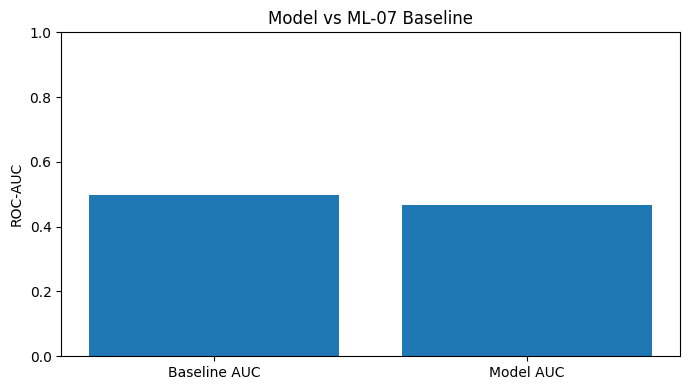

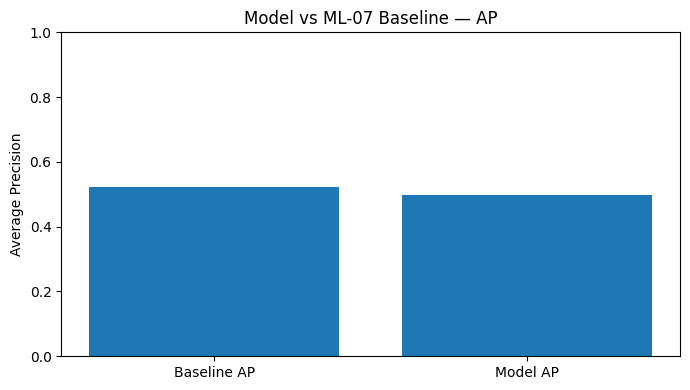

In [11]:
if "model_auc" in globals():
    plt.figure(figsize=(7, 4))
    plt.bar(
        ["Baseline AUC", "Model AUC"],
        [baseline_auc, model_auc]
    )
    plt.ylabel("ROC-AUC")
    plt.title("Model vs ML-07 Baseline")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.bar(
        ["Baseline AP", "Model AP"],
        [baseline_ap, model_ap]
    )
    plt.ylabel("Average Precision")
    plt.title("Model vs ML-07 Baseline — AP")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()
else:
    print("No comparable two-class evaluation available.")


## 7. Ranked recommendations

The model ranks the holdout items by predicted recovery probability.

A high score is a prioritization signal, not proof that changing a page will cause recovery. Human review is required.


In [12]:
ranked = holdout_model.copy()

ranked["action_label"] = np.where(
    ranked["model_score"] >= 0.5,
    "Prioritize recovery review",
    "Monitor / lower priority"
)

ranked["reason_code"] = np.where(
    ranked["position_change_7d"] > 0,
    "POSITION_DECLINE",
    "RECOVERY_REVIEW"
)

ranked = ranked.sort_values(
    ["model_score", "current_impressions"],
    ascending=[False, False]
).reset_index(drop=True)

top10 = ranked.head(10)

print("Top-10 recommendations:")
display(
    top10[
        [
            "content_hash_id",
            "client_hash_id",
            "model_score",
            "reason_code",
            "action_label",
            "current_position",
            "position_7d_avg",
            "position_change_7d",
            "current_clicks",
            "current_impressions"
        ]
    ]
)


Top-10 recommendations:


,content_hash_id,client_hash_id,model_score,reason_code,action_label,current_position,position_7d_avg,position_change_7d,current_clicks,current_impressions
0,content_34a70fea29d15f24,client_62f4a7e64f5e0096,0.961823,POSITION_DECLINE,Prioritize recovery review,3.626333,2.984749,2.639154,1,19223
1,content_1642f339bd6e7c8d,client_62f4a7e64f5e0096,0.940421,POSITION_DECLINE,Prioritize recovery review,5.131579,3.553788,2.350810,1,16454
2,content_74de5f247659e956,client_23a62021009f63c4,0.935397,POSITION_DECLINE,Prioritize recovery review,18.572293,2.165923,17.087343,170,10907
3,content_b99ea6861864dea5,client_62f4a7e64f5e0096,0.889775,POSITION_DECLINE,Prioritize recovery review,4.924530,3.968329,1.697307,16,11965
4,content_ec2e0346994fb5a5,client_e547b89c05043229,0.887874,POSITION_DECLINE,Prioritize recovery review,3.222233,2.392573,0.721019,69,10255
5,content_65c75874a23fca87,client_23a62021009f63c4,0.838532,RECOVERY_REVIEW,Prioritize recovery review,7.168842,5.862306,-0.551014,1,9885
6,content_e7b5dd4dff461ad2,client_08a6a72ff48e62c0,0.818481,POSITION_DECLINE,Prioritize recovery review,5.092970,4.189985,1.076853,65,7013
7,content_e7b5dd4dff461ad2,client_08a6a72ff48e62c0,0.800773,POSITION_DECLINE,Prioritize recovery review,5.593538,4.514814,1.638369,64,6345
8,content_8f06931116dbb8bf,client_23a62021009f63c4,0.799651,POSITION_DECLINE,Prioritize recovery review,31.194082,20.218783,13.854132,40,7435
9,content_8e1334d6356668e3,client_73cda7b4e4f265ea,0.793128,POSITION_DECLINE,Prioritize recovery review,5.238294,3.903914,2.188294,1,7902


In [13]:
print("Top-10 review")

for i, row in top10.iterrows():
    print(
        f"{i+1}. {row['content_hash_id']} | "
        f"{row['action_label']} | "
        f"score={row['model_score']:.4f}"
    )
    print(
        "   Why: the model ranks this item highly using "
        "decision-time position and engagement features."
    )
    print(
        "   What would make it wrong: search intent, SERP features, "
        "query mix, business priority, tracking quality, or missing history."
    )


Top-10 review
1. content_34a70fea29d15f24 | Prioritize recovery review | score=0.9618
   Why: the model ranks this item highly using decision-time position and engagement features.
   What would make it wrong: search intent, SERP features, query mix, business priority, tracking quality, or missing history.
2. content_1642f339bd6e7c8d | Prioritize recovery review | score=0.9404
   Why: the model ranks this item highly using decision-time position and engagement features.
   What would make it wrong: search intent, SERP features, query mix, business priority, tracking quality, or missing history.
3. content_74de5f247659e956 | Prioritize recovery review | score=0.9354
   Why: the model ranks this item highly using decision-time position and engagement features.
   What would make it wrong: search intent, SERP features, query mix, business priority, tracking quality, or missing history.
4. content_b99ea6861864dea5 | Prioritize recovery review | score=0.8898
   Why: the model ranks this ite

## 8. Failure points and human review

Known limitations:

- `recovery_label` is a proxy, not a causal measure.
- Some histories do not contain enough prior observations for the trailing 7-day features.
- GSC availability differs across clients.
- A high score does not prove that a content refresh will improve rankings.
- The exact ML-07 staleness field is not part of the five-feature warehouse contract. The notebook does not fabricate it.
- Human review should check search intent, SERP context, business priority, and tracking quality.


In [14]:
# Final self-check and receipts
os.makedirs("work/outputs", exist_ok=True)

metrics = {
    "training_rows": int(len(train_model)),
    "holdout_rows": int(len(holdout_model)),
    "comparable_holdout_rows": int(len(eval_df)),
    "model_auc": float(model_auc) if "model_auc" in globals() else None,
    "model_ap": float(model_ap) if "model_ap" in globals() else None,
    "baseline_auc": float(baseline_auc) if "baseline_auc" in globals() else None,
    "baseline_ap": float(baseline_ap) if "baseline_ap" in globals() else None,
    "leak_correlation": float(leak_corr),
    "baseline_source": baseline_source_used
}

pd.DataFrame([metrics]).to_json(
    "work/outputs/capstone_metrics.json",
    orient="records",
    indent=2
)

ranked.head(100).to_csv(
    "work/outputs/capstone_ranked_recommendations.csv",
    index=False
)

print("=== SELF-CHECK ===")
print("Five features:", feature_cols)
print("Recovery label used as feature:", "recovery_label" in feature_cols)
print("Leaky feature used as feature:", "leaky_feature" in feature_cols)
print("Top-10 generated:", len(top10) == 10)
print("Metrics receipt: work/outputs/capstone_metrics.json")
print("Recommendation output: work/outputs/capstone_ranked_recommendations.csv")
print("Run the notebook top-to-bottom before committing.")


=== SELF-CHECK ===
Five features: ['current_position', 'position_7d_avg', 'position_change_7d', 'current_clicks', 'current_impressions']
Recovery label used as feature: False
Leaky feature used as feature: False
Top-10 generated: True
Metrics receipt: work/outputs/capstone_metrics.json
Recommendation output: work/outputs/capstone_ranked_recommendations.csv
Run the notebook top-to-bottom before committing.
